STAGE 1/3: Main comparison (DQN vs DDPG vs PPO vs Q-Learning vs baselines)
[seed 0] training DQN / DDPG / PPO / Q-Learning (1500 steps each)...
[seed 1] training DQN / DDPG / PPO / Q-Learning (1500 steps each)...
[seed 2] training DQN / DDPG / PPO / Q-Learning (1500 steps each)...
[seed 3] training DQN / DDPG / PPO / Q-Learning (1500 steps each)...
[seed 4] training DQN / DDPG / PPO / Q-Learning (1500 steps each)...
Training + evaluation complete in 62.5s across 5 seeds.

| Method | Avg Reward | Std | Secrecy Rate | BER | Energy | vs Static (%) | vs TBHP (%) |
|---|---|---|---|---|---|---|---|
| DQN | 12.3372 | 5.1600 | 2.7454 | 0.0634 | 1.3579 | 80.8704 | 48.2238 |
| DDPG | 13.9804 | 4.6745 | 3.1792 | 0.0297 | 1.9010 | 104.9606 | 67.9657 |
| PPO | 8.4165 | 3.7832 | 1.9065 | 0.0586 | 1.0868 | 23.3913 | 1.1195 |
| Q-Learning | 10.7699 | 4.3406 | 2.3796 | 0.0752 | 1.0903 | 57.8934 | 29.3940 |
| Static Random | 6.8210 | 3.1262 | 1.5788 | 0.0780 | 1.0341 | 0.0000 | -18.0497 |
| TBHP | 8.32

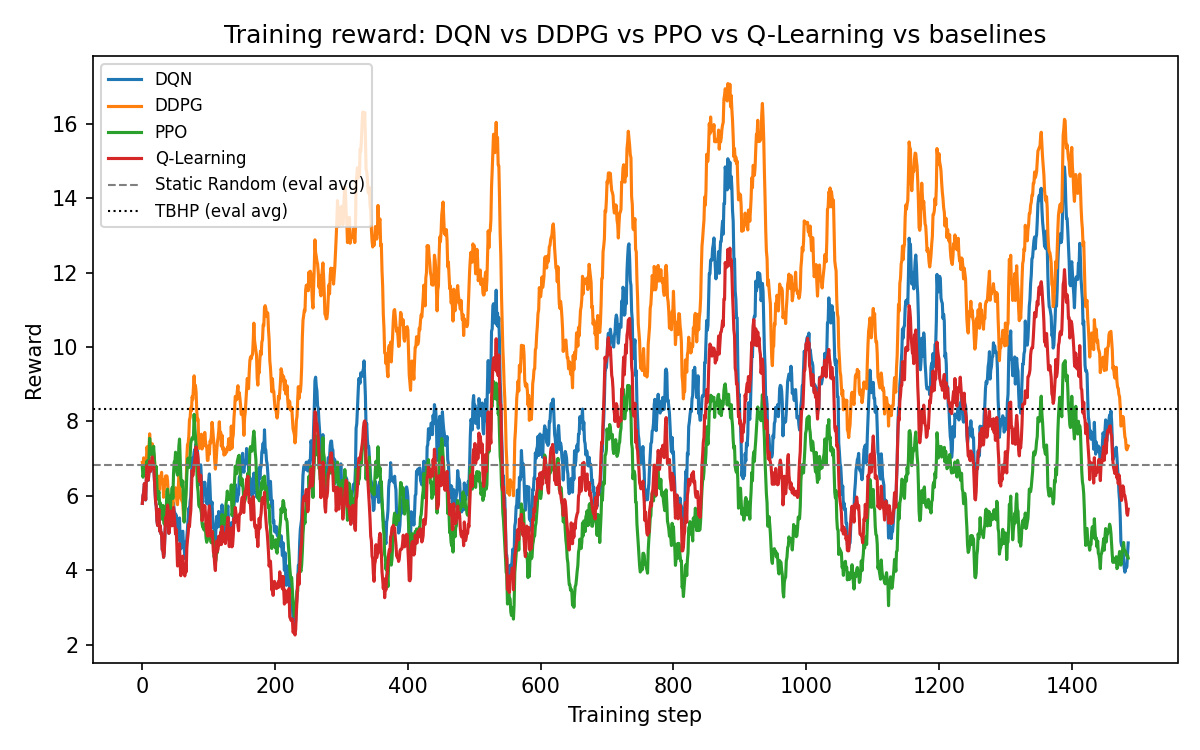


STAGE 2/3: Reward-weight ablation (beta_energy, gamma_ber)
Sweeping beta_energy in [0.5, 1.0, 1.5, 2.0] (gamma_ber fixed at 0.5)...
Sweeping gamma_ber in [0.25, 0.5, 0.75, 1.0] (beta_energy fixed at 1.0)...

| Sweep | Value | Final Reward | Final Secrecy Rate | Final BER |
|---|---|---|---|---|
| beta_energy | 0.5000 | 9.5806 | 2.0633 | 0.0888 |
| beta_energy | 1.0000 | 8.8730 | 2.0594 | 0.0913 |
| beta_energy | 1.5000 | 8.2170 | 2.0750 | 0.0916 |
| beta_energy | 2.0000 | 7.7092 | 2.0369 | 0.0978 |
| gamma_ber | 0.2500 | 9.0119 | 2.0788 | 0.0927 |
| gamma_ber | 0.5000 | 8.8730 | 2.0594 | 0.0913 |
| gamma_ber | 0.7500 | 8.8180 | 2.0270 | 0.0970 |
| gamma_ber | 1.0000 | 9.0379 | 2.0734 | 0.0899 |

Saved: results/ablation_reward_weights.csv
Saved: results/ablation_reward_weights.png


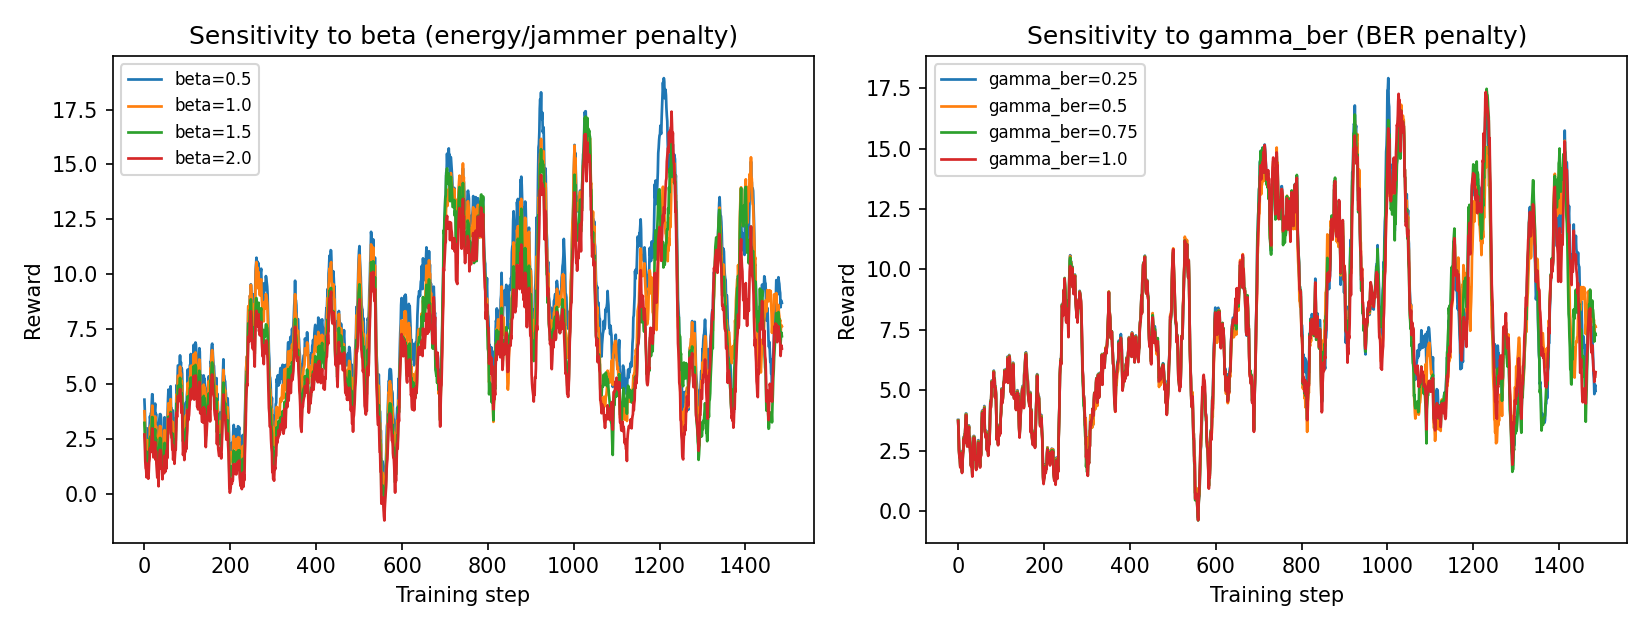


STAGE 3/3: Multi-agent / colluding-eavesdropper scenarios
Running scenario: 1 jammer / 1 eve (baseline) ...
Running scenario: 3 jammers / 1 eve ...
Running scenario: 1 jammer / 3 eves (non-colluding) ...
Running scenario: 1 jammer / 3 eves (colluding) ...
Running scenario: 3 jammers / 3 eves (colluding, worst case) ...

| Scenario | Method | Avg Reward | Avg Secrecy Rate | vs Static (%) | vs TBHP (%) |
|---|---|---|---|---|---|
| 1 jammer / 1 eve (baseline) | DQN | 10.8249 | 2.4796 | 77.8074 | 41.1620 |
| 1 jammer / 1 eve (baseline) | DDPG | 13.0373 | 3.0106 | 114.1479 | 70.0128 |
| 1 jammer / 1 eve (baseline) | Static Random | 6.0880 | 1.4316 | 0.0000 | -20.6096 |
| 1 jammer / 1 eve (baseline) | TBHP | 7.6684 | 1.7924 | 25.9599 | 0.0000 |
| 3 jammers / 1 eve | DQN | 4.2243 | 1.1223 | 211.7662 | 67.4611 |
| 3 jammers / 1 eve | DDPG | 5.3387 | 1.4778 | 294.0140 | 111.6395 |
| 3 jammers / 1 eve | Static Random | 1.3550 | 0.4954 | 0.0000 | -46.2863 |
| 3 jammers / 1 eve | TBHP | 2.5226 |

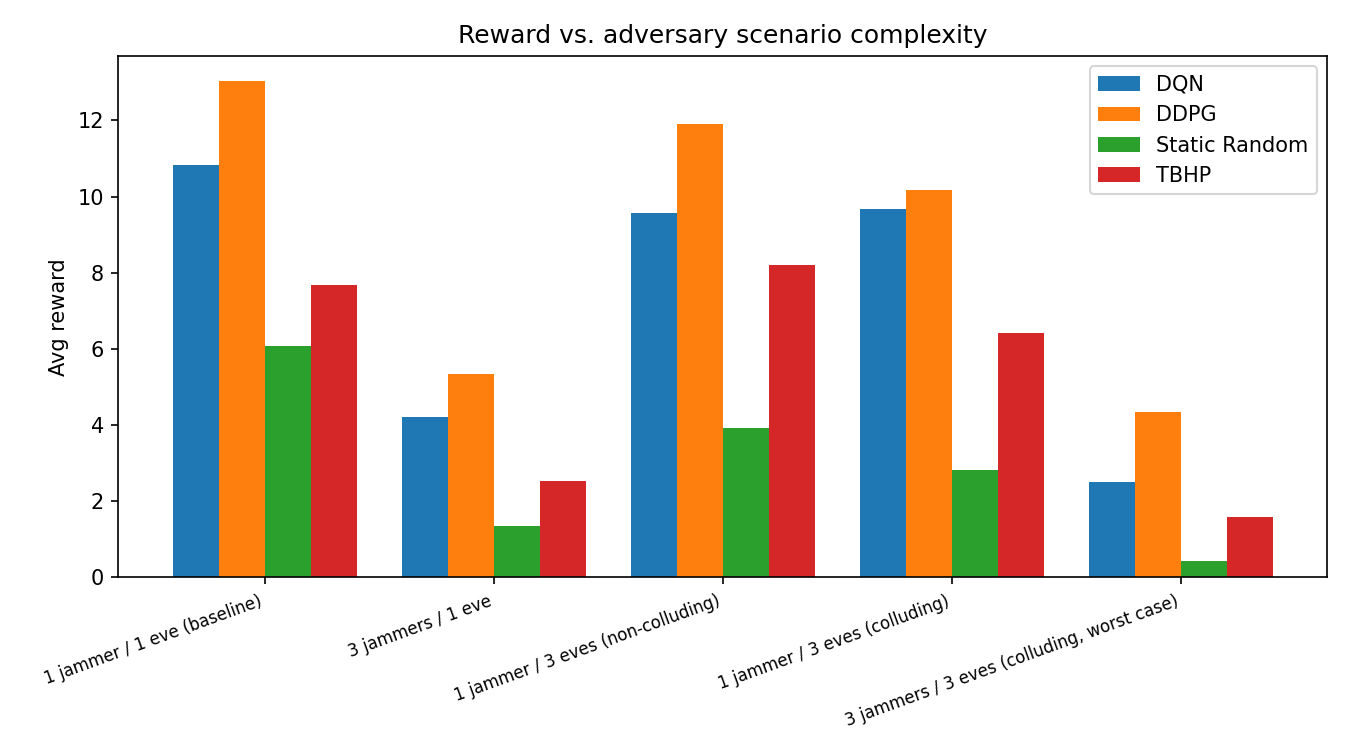


All stages complete in 259.7s. Outputs written to: results/


In [3]:
"""
plsec6g_colab.py
==================
Single-file version of the plsec6g journal-expansion codebase, merged for
Google Colab (or any single-script use).

Combines: channel_models, environment, baselines, agents (DQN/DDPG/PPO/
tabular Q-learning), evaluation, utils, and all three experiment drivers
(main comparison, reward-weight ablation, multi-agent scenarios) into one
file. Functionally identical to the multi-file version; only two internal
function names changed to avoid collisions once merged into one namespace
(ablation_study.main -> run_ablation_study, multi_agent_experiment.main ->
run_multi_agent_experiment), and the argparse CLI was replaced with a plain
CONFIG block below (argparse breaks inside notebook cells because Colab/
Jupyter injects its own kernel-launch arguments into sys.argv).

HOW TO USE IN COLAB
--------------------
Easiest: new Colab notebook -> paste this ENTIRE file into one cell -> edit
the CONFIG block below if you want -> Shift+Enter. Figures display inline
automatically (Colab's default backend supports it) AND are saved as PNGs
under OUTDIR; tables are saved as .csv/.md. At the end, if actually running
in Colab, the results folder is zipped and a browser download is triggered
automatically.

Alternative: upload this file to Colab's Files panel, then in a cell run
`!python plsec6g_colab.py`. This runs as a detached subprocess, so figures
won't display inline -- view the saved PNGs afterward with, e.g.,
`from IPython.display import Image; Image("results/fig2_training_curves.png")`.

Dependencies (numpy, scipy, matplotlib, torch) are preinstalled in the
default Colab runtime. Outside Colab: `pip install numpy scipy matplotlib torch`.
"""
from __future__ import annotations

# ============================== CONFIG ====================================
# Edit these directly, then re-run the cell -- no command-line flags needed.
TRAIN_STEPS   = 1500     # training timesteps per method per seed. Paper-scale: 5000-20000
SEEDS         = 5        # independent training+eval runs. Paper-scale: 10 (matches Table II)
EPISODE_LEN   = 50
EVAL_EPISODES = 5
OUTDIR        = "results"
RUN_MAIN_COMPARISON = True   # DQN vs DDPG vs PPO vs Q-Learning vs baselines (extended Table II / Fig. 2)
RUN_ABLATION        = True   # beta_energy / gamma_ber reward-weight sweep
RUN_MULTI_AGENT     = True   # multi-jammer / colluding-eavesdropper scenarios
# ===========================================================================

import os
import time
import random
import itertools
import contextlib
import io
from dataclasses import dataclass

import numpy as np
from scipy.special import erfc
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F


# ===========================================================================
# SECTION: channel_models
# ---------------------------------------------------------------------------
# Information-theoretic and small/large-scale fading channel model. Implements,
# with direct correspondence to the journal-expansion equations:
#   Large-scale path loss   : log-distance model            -> path_loss_db()
#   Small-scale fading      : Rayleigh (NLOS) / Rician (LOS) -> rayleigh_gain(), rician_gain()
#   Composite channel gain  :                                  channel_power_gain()
#   Legitimate link SINR    : C_b = log2(1 + Pt|h_b|^2 / (N0 + Pj|h_j|^2))
#   Eavesdropper link SINR  : C_e = log2(1 + Pt|h_e|^2 / (N0 + Pn|h_n|^2))
#   Shannon capacity        :                                  shannon_capacity()
#   Secrecy capacity        : Rs = [C_b - C_e]^+               secrecy_capacity()
#   Bit error rate          : BPSK BER from SINR               ber_bpsk()
# All power quantities are handled in LINEAR scale internally.
# ===========================================================================

def path_loss_db(
    distance: np.ndarray | float,
    d0: float = 1.0,
    pl_d0_db: float = 61.4,
    path_loss_exponent: float = 2.2,
    shadowing_std_db: float = 0.0,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Log-distance path loss with optional log-normal shadowing:
        PL(d)[dB] = PL(d0) + 10 * n * log10(d / d0) + X_sigma,  X_sigma ~ N(0, sigma^2)
    Defaults (pl_d0_db=61.4, n=2.2) correspond to a representative sub-THz /
    mmWave 6G link budget at d0 = 1 m -- reproducibility parameters; cite/
    replace with your own link-budget numbers as needed for the journal text.
    """
    d = np.maximum(np.asarray(distance, dtype=np.float64), d0)
    pl = pl_d0_db + 10.0 * path_loss_exponent * np.log10(d / d0)
    if shadowing_std_db > 0:
        rng = rng or np.random.default_rng()
        pl = pl + rng.normal(0.0, shadowing_std_db, size=np.shape(pl))
    return pl


def db_to_linear(db: np.ndarray | float) -> np.ndarray:
    return 10.0 ** (np.asarray(db, dtype=np.float64) / 10.0)


def rayleigh_gain(size: int = 1, rng: np.random.Generator | None = None) -> np.ndarray:
    """NLOS small-scale fading: h ~ CN(0,1) so |h|^2 ~ Exp(1)."""
    rng = rng or np.random.default_rng()
    sigma = np.sqrt(0.5)
    h = rng.normal(0.0, sigma, size) + 1j * rng.normal(0.0, sigma, size)
    return h


def rician_gain(k_factor: float, size: int = 1, rng: np.random.Generator | None = None) -> np.ndarray:
    """LOS small-scale fading with Rician K-factor (linear, not dB). Normalized
    so that E[|h|^2] = 1 for any K, matching the Rayleigh case when K -> 0."""
    rng = rng or np.random.default_rng()
    k_factor = max(k_factor, 0.0)
    los_amplitude = np.sqrt(k_factor / (k_factor + 1.0))
    scatter_sigma = np.sqrt(1.0 / (2.0 * (k_factor + 1.0)))
    h_los = los_amplitude
    h_nlos = rng.normal(0.0, scatter_sigma, size) + 1j * rng.normal(0.0, scatter_sigma, size)
    return h_los + h_nlos


def channel_power_gain(
    distance: np.ndarray | float,
    fading: str = "rayleigh",
    k_factor: float = 4.0,
    d0: float = 1.0,
    pl_d0_db: float = 61.4,
    path_loss_exponent: float = 2.2,
    shadowing_std_db: float = 0.0,
    rng: np.random.Generator | None = None,
) -> np.ndarray | float:
    """
    Composite instantaneous channel power gain |h|^2 = path-loss * |h_fast|^2.
    Returns a plain Python float if `distance` was scalar, otherwise a
    real-valued array matching `distance`'s shape. (NumPy >=2 raises on
    float() of a shape-(1,) array, so scalar vs. array is handled explicitly.)
    """
    rng = rng or np.random.default_rng()
    distance_arr = np.asarray(distance, dtype=np.float64)
    scalar_input = (distance_arr.ndim == 0)
    pl_db = path_loss_db(distance_arr, d0, pl_d0_db, path_loss_exponent, shadowing_std_db, rng)
    pl_linear = db_to_linear(-pl_db)
    size = 1 if scalar_input else distance_arr.shape
    if fading == "rayleigh":
        h_fast = rayleigh_gain(size, rng)
    elif fading == "rician":
        h_fast = rician_gain(k_factor, size, rng)
    else:
        raise ValueError(f"Unknown fading type: {fading!r} (expected 'rayleigh' or 'rician')")
    result = pl_linear * np.abs(h_fast) ** 2
    if scalar_input:
        return float(np.asarray(result).reshape(-1)[0])
    return result


def sinr_legit(pt: float, g_b: float, p_j_agg: float, g_j_agg: float,
               n0: float, an_leakage: float = 0.0, nt: float = 0.0, g_an_b: float | None = None) -> float:
    """SINR_b = Pt*g_b / (N0 + Pj_agg*g_j_agg + an_leakage*Nt*g_an_b).
    `an_leakage` models imperfect null-space AN injection reaching the legit user."""
    g_an_b = g_b if g_an_b is None else g_an_b
    interference = p_j_agg * g_j_agg + an_leakage * nt * g_an_b
    return (pt * g_b) / (n0 + interference)


def sinr_eve(pt: float, g_e: float, nt: float, g_an_e: float, n0: float,
             p_j_agg: float = 0.0, g_j_e: float = 0.0) -> float:
    """SINR_e = Pt*g_e / (N0 + Nt*g_an_e + Pj_agg*g_j_e). Optional jammer-to-eve
    term disabled by default (g_j_e=0) to match the base equation; exposed as a
    realism toggle."""
    interference = nt * g_an_e + p_j_agg * g_j_e
    return (pt * g_e) / (n0 + interference)


def shannon_capacity(sinr_linear: np.ndarray | float) -> np.ndarray:
    return np.log2(1.0 + np.maximum(sinr_linear, 0.0))


def secrecy_capacity(c_b: np.ndarray | float, c_e: np.ndarray | float) -> np.ndarray:
    """Rs = [Cb - Ce]^+"""
    return np.maximum(np.asarray(c_b) - np.asarray(c_e), 0.0)


def ber_bpsk(sinr_linear: np.ndarray | float) -> np.ndarray:
    """BER of BPSK over the legitimate link given its SINR: 0.5*erfc(sqrt(SINR))."""
    s = np.maximum(np.asarray(sinr_linear, dtype=np.float64), 0.0)
    return 0.5 * erfc(np.sqrt(s))


def beam_directivity(w: np.ndarray | float, g_max: float = 4.0) -> np.ndarray:
    """Directivity gain toward the legit user vs. beamforming-focus action w in
    [0,1]. w=0 -> quasi-omni (1x), w=1 -> fully focused (g_max x). A simplified
    abstraction of a full array-factor/steering-vector model."""
    w = np.clip(w, 0.0, 1.0)
    return 1.0 + (g_max - 1.0) * w


def beam_leakage(w: np.ndarray | float, rho: float = 0.85, floor: float = 0.1) -> np.ndarray:
    """Fraction of signal power leaking toward a spatially-separated
    eavesdropper as beam focus w increases: leakage(w=0)=1, leakage(w=1)=floor."""
    w = np.clip(w, 0.0, 1.0)
    return np.clip(1.0 - rho * w, floor, 1.0)


def calibrate_noise_floor(
    pt_max: float, d_ref: float, target_snr_db: float, d0: float = 1.0,
    pl_d0_db: float = 61.4, path_loss_exponent: float = 2.2,
) -> tuple[float, float]:
    """
    Real link budgets (dBm transmit power, ~-100 dBm thermal noise floors)
    combined with a literal log-distance path loss in dB make raw linear SINR
    collapse to ~0 unless every constant is tuned jointly -- a simulation-
    scaling issue, not a modeling error. We keep the *functional form* of path
    loss/fading exact and calibrate N0 so the AVERAGE SNR at a chosen
    reference distance d_ref, under max transmit power, equals a target
    operating point (target_snr_db) -- standard practice in system-level RL/
    PLS simulation studies; report it as such. Returns (n0, avg_path_gain_at_d_ref).
    """
    pl_db = path_loss_db(d_ref, d0, pl_d0_db, path_loss_exponent)
    avg_gain = float(db_to_linear(-pl_db))
    target_snr_linear = float(db_to_linear(target_snr_db))
    n0 = pt_max * avg_gain / target_snr_linear
    return n0, avg_gain


# ===========================================================================
# SECTION: environment
# ---------------------------------------------------------------------------
# The physical layer security MDP environment used by every agent and both
# baselines. Replaces the conference prototype's normalized-float toy state
# S_t = [s, p_j, n, d_e] with a physically-grounded observation built from
# actual channel realizations, keeping the SAME MDP structure and reward form
# R_t = alpha*Rs - beta*E - gamma_ber*BER (Eq. 4).
#
# Design notes:
#  * Block fading: large-scale positions/powers evolve as a bounded random
#    walk once per step; small-scale fading is redrawn i.i.d. every step.
#  * State is a fixed-length aggregate (7-D) regardless of adversary count,
#    so a policy trained single-adversary is architecture-compatible with
#    the multi-adversary experiments.
#  * Colluding eavesdroppers: modeled via maximal-ratio-combining of their
#    individual SINRs; non-colluding = conservative worst-case single eavesdropper.
# ===========================================================================

STATE_DIM = 7  # fixed regardless of num_jammers / num_eavesdroppers


@dataclass
class PLSEnvConfig:
    num_jammers: int = 1
    num_eavesdroppers: int = 1
    colluding_eavesdroppers: bool = False

    bs_user_distance: float = 50.0
    jammer_distance_range: tuple[float, float] = (5.0, 120.0)
    eve_distance_range: tuple[float, float] = (5.0, 120.0)

    fading_legit: str = "rician"
    fading_adv: str = "rayleigh"
    k_factor: float = 4.0
    path_loss_exponent: float = 2.2
    pl_d0_db: float = 61.4
    shadowing_std_db: float = 4.0

    pt_min: float = 0.05
    pt_max: float = 1.0
    nt_max: float = 0.30
    jammer_power_max: float = 1.0
    an_leakage: float = 0.05
    target_snr_db: float = 10.0

    beam_g_max: float = 4.0
    beam_rho: float = 0.85
    beam_leak_floor: float = 0.10

    alpha: float = 5.0
    beta_energy: float = 1.0
    gamma_ber: float = 0.5

    jammer_power_drift_std: float = 0.03
    jammer_dist_drift_std: float = 3.0
    eve_dist_drift_std: float = 3.0

    episode_len: int = 50
    action_mode: str = "continuous"   # "continuous" or "discrete"
    discrete_bins_per_dim: int = 3    # -> discrete_bins_per_dim**3 total discrete actions


class PLSEnv:
    """Physical-layer-security adaptive transmission MDP."""

    def __init__(self, config: PLSEnvConfig | None = None, seed: int | None = None):
        self.cfg = config or PLSEnvConfig()
        self.rng = np.random.default_rng(seed)

        self.n0, self._avg_gain_ref = calibrate_noise_floor(
            pt_max=self.cfg.pt_max, d_ref=self.cfg.bs_user_distance,
            target_snr_db=self.cfg.target_snr_db, pl_d0_db=self.cfg.pl_d0_db,
            path_loss_exponent=self.cfg.path_loss_exponent,
        )
        self._g_state_norm = max(self._avg_gain_ref, 1e-30)

        bins = self.cfg.discrete_bins_per_dim
        grid_1d = np.linspace(-1.0, 1.0, bins)
        self._discrete_grid = list(itertools.product(grid_1d, repeat=3))
        self.num_discrete_actions = len(self._discrete_grid)
        self.action_dim_continuous = 3
        self.state_dim = STATE_DIM

        self._t = 0
        self.jam_dist = None
        self.jam_power = None
        self.eve_dist = None
        self._cached_channel = None  # (g_b, g_j, g_e) behind the current state
        self.reset(seed=seed)

    def reset(self, seed: int | None = None) -> np.ndarray:
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        c = self.cfg
        self._t = 0
        self.jam_dist = self.rng.uniform(*c.jammer_distance_range, size=c.num_jammers)
        self.jam_power = self.rng.uniform(0.0, c.jammer_power_max, size=c.num_jammers)
        self.eve_dist = self.rng.uniform(*c.eve_distance_range, size=c.num_eavesdroppers)
        self._cached_channel = self._draw_channel()
        return self._build_state(*self._cached_channel)

    def step(self, action):
        pt, w, nt = self._decode_action(action)
        return self.step_physical(pt, w, nt)

    def step_physical(self, pt: float, w: float, nt: float):
        """Step given actions already in physical units. Used directly by RL
        agents (after decoding) and by the static-random/TBHP baselines.

        Scores (pt, w, nt) against `self._cached_channel` -- the SAME channel
        realization that was used to build the state this action was chosen
        from (cached by reset() / the previous call to step_physical()). Only
        after the reward is computed do we draw a fresh channel, for the
        *next* state. Previously a brand-new channel was redrawn here before
        scoring the action, so an action chosen under one fading realization
        was rewarded against an independently-redrawn one -- inconsistent
        with the perfect-CSI assumption of the MDP (see paper limitations)
        and, strictly, not scoring the action against the state it saw.
        """
        c = self.cfg
        pt = float(np.clip(pt, c.pt_min, c.pt_max))
        w = float(np.clip(w, 0.0, 1.0))
        nt = float(np.clip(nt, 0.0, c.nt_max))

        g_b, g_j, g_e = self._cached_channel

        d_b = beam_directivity(w, g_max=c.beam_g_max)
        d_e = beam_leakage(w, rho=c.beam_rho, floor=c.beam_leak_floor)

        jam_interference = float(np.sum(self.jam_power * g_j))
        sinr_b = sinr_legit(
            pt=pt * d_b, g_b=g_b, p_j_agg=jam_interference, g_j_agg=1.0,
            n0=self.n0, an_leakage=c.an_leakage, nt=nt, g_an_b=g_b,
        )
        c_b = float(shannon_capacity(sinr_b))

        sinr_e_each = np.array([
            sinr_eve(pt=pt * d_e, g_e=g_e[m], nt=nt, g_an_e=g_e[m], n0=self.n0)
            for m in range(c.num_eavesdroppers)
        ])
        if c.colluding_eavesdroppers:
            sinr_e_eff = float(np.sum(sinr_e_each))
        else:
            sinr_e_eff = float(np.max(sinr_e_each))
        c_e = float(shannon_capacity(sinr_e_eff))

        rs = float(secrecy_capacity(c_b, c_e))
        ber = float(ber_bpsk(sinr_b))
        energy = pt / c.pt_max + nt / max(c.nt_max, 1e-9)

        reward = c.alpha * rs - c.beta_energy * energy - c.gamma_ber * ber

        self._advance_adversaries()
        self._t += 1
        done = self._t >= c.episode_len

        info = dict(
            sinr_b=sinr_b, sinr_e=sinr_e_eff, c_b=c_b, c_e=c_e,
            secrecy_rate=rs, ber=ber, energy=energy, pt=pt, w=w, nt=nt,
            reward_secrecy_term=c.alpha * rs, reward_energy_term=c.beta_energy * energy,
            reward_ber_term=c.gamma_ber * ber,
        )
        self._cached_channel = self._draw_channel()
        next_state = self._build_state(*self._cached_channel)
        return next_state, reward, done, info

    def _draw_channel(self):
        """Draws one fresh small-scale-fading realization (g_b, g_j, g_e) for
        the CURRENT jam_dist/eve_dist. Called exactly once per step -- in
        reset() and again at the end of step_physical() -- and cached, so the
        channel used to build a state is always the same one later used to
        score whatever action is taken from that state."""
        c = self.cfg
        g_b = float(channel_power_gain(
            c.bs_user_distance, fading=c.fading_legit, k_factor=c.k_factor,
            pl_d0_db=c.pl_d0_db, path_loss_exponent=c.path_loss_exponent,
            shadowing_std_db=c.shadowing_std_db, rng=self.rng))

        g_j = channel_power_gain(
            self.jam_dist, fading=c.fading_adv, pl_d0_db=c.pl_d0_db,
            path_loss_exponent=c.path_loss_exponent, shadowing_std_db=c.shadowing_std_db,
            rng=self.rng)

        g_e = channel_power_gain(
            self.eve_dist, fading=c.fading_adv, pl_d0_db=c.pl_d0_db,
            path_loss_exponent=c.path_loss_exponent, shadowing_std_db=c.shadowing_std_db,
            rng=self.rng)
        return g_b, g_j, g_e

    def _advance_adversaries(self):
        c = self.cfg
        self.jam_power = np.clip(
            self.jam_power + self.rng.normal(0, c.jammer_power_drift_std, size=c.num_jammers),
            0.0, c.jammer_power_max)
        self.jam_dist = np.clip(
            self.jam_dist + self.rng.normal(0, c.jammer_dist_drift_std, size=c.num_jammers),
            *c.jammer_distance_range)
        self.eve_dist = np.clip(
            self.eve_dist + self.rng.normal(0, c.eve_dist_drift_std, size=c.num_eavesdroppers),
            *c.eve_distance_range)

    def _build_state(self, g_b: float, g_j: np.ndarray, g_e: np.ndarray) -> np.ndarray:
        """Builds the observation from one channel realization (g_b, g_j,
        g_e). Always called on `self._cached_channel`, i.e. the exact channel
        that will subsequently be used to score the action taken from this
        state -- so every state feature reflects the same channel snapshot
        instead of mixing a stale draw (channel features) with feedback from
        an action scored against a different, later draw."""
        c = self.cfg
        jam_interference = float(np.sum(self.jam_power * g_j))

        g_b_norm = np.clip(g_b / self._g_state_norm, 0.0, 5.0)
        jam_interference_norm = np.clip(jam_interference / self._g_state_norm, 0.0, 5.0)
        jam_power_agg_norm = float(np.clip(np.sum(self.jam_power) / (c.num_jammers * c.jammer_power_max), 0.0, 1.0))
        jam_dist_norm = float(np.clip(
            (np.min(self.jam_dist) - c.jammer_distance_range[0]) /
            max(c.jammer_distance_range[1] - c.jammer_distance_range[0], 1e-9), 0.0, 1.0))

        eve_metric = np.sum(g_e) if c.colluding_eavesdroppers else np.max(g_e)
        eve_metric_norm = float(np.clip(eve_metric / self._g_state_norm, 0.0, 5.0))
        eve_dist_norm = float(np.clip(
            (np.min(self.eve_dist) - c.eve_distance_range[0]) /
            max(c.eve_distance_range[1] - c.eve_distance_range[0], 1e-9), 0.0, 1.0))

        t_frac = self._t / max(c.episode_len, 1)

        return np.array([
            g_b_norm, jam_interference_norm, jam_power_agg_norm,
            jam_dist_norm, eve_metric_norm, eve_dist_norm, t_frac
        ], dtype=np.float32)

    def _decode_action(self, action):
        c = self.cfg
        if c.action_mode == "discrete":
            a1, a2, a3 = self._discrete_grid[int(action)]
        else:
            a1, a2, a3 = np.clip(np.asarray(action, dtype=np.float64), -1.0, 1.0)
        pt = c.pt_min + (c.pt_max - c.pt_min) * (a1 + 1.0) / 2.0
        w = (a2 + 1.0) / 2.0
        nt = c.nt_max * (a3 + 1.0) / 2.0
        return pt, w, nt


# ===========================================================================
# SECTION: baselines
# ---------------------------------------------------------------------------
# Non-adaptive baselines, matching the conference-paper baselines but adapted
# to the physically-grounded state/action space. Both act in *physical* units
# (Pt, w, Nt) and step the environment via env.step_physical(...), exactly
# like the learned agents after action decoding.
# ===========================================================================

class StaticRandomPolicy:
    """Uniformly samples the full physical action space at every step."""

    def __init__(self, cfg: PLSEnvConfig, seed: int | None = None):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)

    def act(self, state: np.ndarray) -> tuple[float, float, float]:
        pt = self.rng.uniform(self.cfg.pt_min, self.cfg.pt_max)
        w = self.rng.uniform(0.0, 1.0)
        nt = self.rng.uniform(0.0, self.cfg.nt_max)
        return pt, w, nt


class TBHPPolicy:
    """
    Threshold-Based Heuristic Policy (domain-knowledge rules, no learning).
    State layout: [0]=g_b_norm ("signal strength"), [1]=jam_interference_norm,
    [2]=jam_power_agg_norm, [3]=jam_dist_norm, [4]=eve_metric_norm,
    [5]=eve_dist_norm, [6]=t_frac.
    """

    def __init__(self, cfg: PLSEnvConfig, signal_threshold: float = 0.8,
                 eve_threshold: float = 0.7):
        self.cfg = cfg
        self.signal_threshold = signal_threshold
        self.eve_threshold = eve_threshold

    def act(self, state: np.ndarray) -> tuple[float, float, float]:
        c = self.cfg
        g_b_norm, _, _, _, _, eve_dist_norm, _ = state
        pt = c.pt_max if g_b_norm < self.signal_threshold else 0.5 * (c.pt_min + c.pt_max)
        if eve_dist_norm < self.eve_threshold:
            nt = c.nt_max
            w = 0.8
        else:
            nt = 0.05 * c.nt_max
            w = 0.3
        return pt, w, nt


# ===========================================================================
# SECTION: agents
# ---------------------------------------------------------------------------
# DQNAgent (discrete, conference method formalized), DDPGAgent (continuous,
# off-policy deterministic), PPOAgent (continuous, on-policy stochastic),
# QLearningAgent (classical tabular baseline). DQN and tabular Q-learning
# share the same Bellman target y_t = R_t + gamma*max_a' Q(S_{t+1},a';theta^-);
# only the function representation of Q differs.
# ===========================================================================

def build_mlp(in_dim: int, out_dim: int, hidden: int = 64, out_activation=None) -> nn.Module:
    layers = [nn.Linear(in_dim, hidden), nn.ReLU(),
              nn.Linear(hidden, hidden), nn.ReLU(),
              nn.Linear(hidden, out_dim)]
    if out_activation is not None:
        layers.append(out_activation)
    return nn.Sequential(*layers)


class ReplayBuffer:
    """Fixed-capacity FIFO replay buffer (Table I: size 10,000, batch 32)."""

    def __init__(self, capacity: int = 10_000, seed: int | None = None):
        from collections import deque
        self.buffer = deque(maxlen=capacity)
        self.rng = random.Random(seed)

    def push(self, s, a, r, s2, done):
        self.buffer.append((s, a, r, s2, done))

    def sample(self, batch_size: int):
        batch = self.rng.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (np.array(s, dtype=np.float32), np.array(a),
                np.array(r, dtype=np.float32), np.array(s2, dtype=np.float32),
                np.array(d, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    """Deep Q-Network with experience replay and a target network (Mnih et al., 2015)."""

    def __init__(self, state_dim: int, num_actions: int, hidden: int = 64, lr: float = 1e-3,
                 gamma: float = 0.99, buffer_size: int = 10_000, batch_size: int = 32,
                 eps_start: float = 1.0, eps_end: float = 0.05, eps_decay_steps: int = 5000,
                 target_update_freq: int = 200, seed: int | None = None, device: str = "cpu"):
        torch.manual_seed(seed if seed is not None else 0)
        self.device = torch.device(device)
        self.num_actions = num_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.eps_start, self.eps_end, self.eps_decay_steps = eps_start, eps_end, eps_decay_steps
        self.target_update_freq = target_update_freq
        self.rng = np.random.default_rng(seed)

        self.q = build_mlp(state_dim, num_actions, hidden).to(self.device)
        self.q_target = build_mlp(state_dim, num_actions, hidden).to(self.device)
        self.q_target.load_state_dict(self.q.state_dict())
        self.opt = torch.optim.Adam(self.q.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size, seed=seed)
        self.total_steps = 0

    def epsilon(self) -> float:
        frac = min(1.0, self.total_steps / max(self.eps_decay_steps, 1))
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    def select_action(self, state: np.ndarray, greedy: bool = False) -> int:
        eps = 0.0 if greedy else self.epsilon()
        if self.rng.random() < eps:
            return int(self.rng.integers(self.num_actions))
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            return int(torch.argmax(self.q(s), dim=1).item())

    def store(self, s, a, r, s2, done):
        self.buffer.push(s, a, r, s2, float(done))
        self.total_steps += 1

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None
        s, a, r, s2, d = self.buffer.sample(self.batch_size)
        s = torch.as_tensor(s, device=self.device)
        a = torch.as_tensor(a, dtype=torch.int64, device=self.device)
        r = torch.as_tensor(r, device=self.device)
        s2 = torch.as_tensor(s2, device=self.device)
        d = torch.as_tensor(d, device=self.device)

        q_sa = self.q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            max_q_next = self.q_target(s2).max(dim=1).values
            y = r + self.gamma * (1.0 - d) * max_q_next  # Bellman target
        loss = F.mse_loss(q_sa, y)

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()
        if self.total_steps % self.target_update_freq == 0:
            self.q_target.load_state_dict(self.q.state_dict())
        return float(loss.item())


class DDPGAgent:
    """Deep Deterministic Policy Gradient (Lillicrap et al., 2016)."""

    def __init__(self, state_dim: int, action_dim: int, hidden: int = 64,
                 actor_lr: float = 1e-3, critic_lr: float = 1e-3, gamma: float = 0.99,
                 tau: float = 0.005, buffer_size: int = 10_000, batch_size: int = 32,
                 noise_std_start: float = 0.4, noise_std_end: float = 0.05,
                 noise_decay_steps: int = 5000, seed: int | None = None, device: str = "cpu"):
        torch.manual_seed(seed if seed is not None else 0)
        self.device = torch.device(device)
        self.gamma, self.tau = gamma, tau
        self.batch_size = batch_size
        self.action_dim = action_dim
        self.noise_std_start, self.noise_std_end = noise_std_start, noise_std_end
        self.noise_decay_steps = noise_decay_steps
        self.rng = np.random.default_rng(seed)

        self.actor = build_mlp(state_dim, action_dim, hidden, out_activation=nn.Tanh()).to(self.device)
        self.actor_target = build_mlp(state_dim, action_dim, hidden, out_activation=nn.Tanh()).to(self.device)
        self.actor_target.load_state_dict(self.actor.state_dict())

        self.critic = build_mlp(state_dim + action_dim, 1, hidden).to(self.device)
        self.critic_target = build_mlp(state_dim + action_dim, 1, hidden).to(self.device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.buffer = ReplayBuffer(buffer_size, seed=seed)
        self.total_steps = 0

    def noise_std(self) -> float:
        frac = min(1.0, self.total_steps / max(self.noise_decay_steps, 1))
        return self.noise_std_start + frac * (self.noise_std_end - self.noise_std_start)

    def select_action(self, state: np.ndarray, greedy: bool = False) -> np.ndarray:
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            a = self.actor(s).cpu().numpy()[0]
        if not greedy:
            a = a + self.rng.normal(0.0, self.noise_std(), size=self.action_dim)
        return np.clip(a, -1.0, 1.0).astype(np.float32)

    def store(self, s, a, r, s2, done):
        self.buffer.push(s, a, r, s2, float(done))
        self.total_steps += 1

    def _soft_update(self, target: nn.Module, source: nn.Module):
        with torch.no_grad():
            for tp, sp in zip(target.parameters(), source.parameters()):
                tp.data.mul_(1.0 - self.tau).add_(self.tau * sp.data)

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None
        s, a, r, s2, d = self.buffer.sample(self.batch_size)
        s = torch.as_tensor(s, device=self.device)
        a = torch.as_tensor(a, dtype=torch.float32, device=self.device)
        r = torch.as_tensor(r, device=self.device)
        s2 = torch.as_tensor(s2, device=self.device)
        d = torch.as_tensor(d, device=self.device)

        with torch.no_grad():
            a2 = self.actor_target(s2)
            q2 = self.critic_target(torch.cat([s2, a2], dim=-1)).squeeze(-1)
            y = r + self.gamma * (1.0 - d) * q2
        q = self.critic(torch.cat([s, a], dim=-1)).squeeze(-1)
        critic_loss = F.mse_loss(q, y)
        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        actor_loss = -self.critic(torch.cat([s, self.actor(s)], dim=-1)).mean()
        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        self._soft_update(self.actor_target, self.actor)
        self._soft_update(self.critic_target, self.critic)
        return float(critic_loss.item()), float(actor_loss.item())


class GaussianActor(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden: int = 64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim) - 0.5)

    def forward(self, s: torch.Tensor):
        h = self.shared(s)
        mean = torch.tanh(self.mean_head(h))
        std = torch.exp(self.log_std).clamp(1e-3, 1.5)
        return mean, std


class RolloutBuffer:
    def __init__(self):
        self.reset()

    def reset(self):
        self.states, self.actions, self.logprobs = [], [], []
        self.rewards, self.dones, self.values = [], [], []

    def add(self, s, a, logp, r, done, v):
        self.states.append(s); self.actions.append(a); self.logprobs.append(logp)
        self.rewards.append(r); self.dones.append(done); self.values.append(v)

    def __len__(self):
        return len(self.states)


class PPOAgent:
    """Proximal Policy Optimization (Schulman et al., 2017) with GAE-lambda advantages."""

    def __init__(self, state_dim: int, action_dim: int, hidden: int = 64, lr: float = 3e-4,
                 gamma: float = 0.99, gae_lambda: float = 0.95, clip_eps: float = 0.2,
                 epochs: int = 10, minibatch_size: int = 32, vf_coef: float = 0.5,
                 ent_coef: float = 0.01, seed: int | None = None, device: str = "cpu"):
        torch.manual_seed(seed if seed is not None else 0)
        self.device = torch.device(device)
        self.gamma, self.gae_lambda, self.clip_eps = gamma, gae_lambda, clip_eps
        self.epochs, self.minibatch_size = epochs, minibatch_size
        self.vf_coef, self.ent_coef = vf_coef, ent_coef

        self.actor = GaussianActor(state_dim, action_dim, hidden).to(self.device)
        self.critic = build_mlp(state_dim, 1, hidden).to(self.device)
        self.opt = torch.optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr)
        self.buffer = RolloutBuffer()

    def select_action(self, state: np.ndarray, greedy: bool = False):
        s = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            mean, std = self.actor(s)
            value = self.critic(s).item()
        if greedy:
            action = mean
            logp = 0.0
        else:
            dist = torch.distributions.Normal(mean, std)
            raw_action = dist.sample()
            logp = dist.log_prob(raw_action).sum(-1).item()
            action = raw_action
        action_np = torch.clamp(action, -1.0, 1.0).cpu().numpy()[0].astype(np.float32)
        return action_np, logp, value

    def store(self, s, a, logp, r, done, v):
        self.buffer.add(s, a, logp, r, done, v)

    def _compute_gae(self, last_value: float):
        rewards, values, dones = self.buffer.rewards, self.buffer.values, self.buffer.dones
        n = len(rewards)
        advantages = np.zeros(n, dtype=np.float32)
        gae = 0.0
        values_ext = values + [last_value]
        for t in reversed(range(n)):
            delta = rewards[t] + self.gamma * values_ext[t + 1] * (1 - dones[t]) - values_ext[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - dones[t]) * gae
            advantages[t] = gae
        returns = advantages + np.array(values, dtype=np.float32)
        return advantages, returns

    def update(self, last_value: float = 0.0) -> float:
        n = len(self.buffer)
        if n == 0:
            return 0.0
        states = torch.as_tensor(np.array(self.buffer.states, dtype=np.float32), device=self.device)
        actions = torch.as_tensor(np.array(self.buffer.actions, dtype=np.float32), device=self.device)
        old_logp = torch.as_tensor(np.array(self.buffer.logprobs, dtype=np.float32), device=self.device)

        advantages, returns = self._compute_gae(last_value)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        advantages_t = torch.as_tensor(advantages, device=self.device)
        returns_t = torch.as_tensor(returns, device=self.device)

        idxs = np.arange(n)
        losses = []
        for _ in range(self.epochs):
            np.random.shuffle(idxs)
            for start in range(0, n, self.minibatch_size):
                mb = idxs[start:start + self.minibatch_size]
                mb_t = torch.as_tensor(mb, dtype=torch.int64, device=self.device)
                mean, std = self.actor(states[mb_t])
                dist = torch.distributions.Normal(mean, std)
                new_logp = dist.log_prob(actions[mb_t]).sum(-1)
                entropy = dist.entropy().sum(-1).mean()
                ratio = torch.exp(new_logp - old_logp[mb_t])
                surr1 = ratio * advantages_t[mb_t]
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * advantages_t[mb_t]
                policy_loss = -torch.min(surr1, surr2).mean()
                value_pred = self.critic(states[mb_t]).squeeze(-1)
                value_loss = F.mse_loss(value_pred, returns_t[mb_t])
                loss = policy_loss + self.vf_coef * value_loss - self.ent_coef * entropy

                self.opt.zero_grad()
                loss.backward()
                self.opt.step()
                losses.append(loss.item())
        self.buffer.reset()
        return float(np.mean(losses))


class QLearningAgent:
    """
    Classical tabular Q-learning (Watkins & Dayan, 1992) using the SAME Bellman
    update as DQN, but with an explicit lookup table instead of a neural
    function approximator. A full 7-D continuous state cannot be tabulated, so
    -- matching standard tabular-RL practice -- only the 3 most decision-
    relevant features are kept and discretized: legit channel gain, aggregate
    jammer interference, eavesdropper distance. This restriction is itself a
    citable motivation for DQN/DDPG/PPO's function approximation.
    """

    FEATURE_IDX = (0, 1, 5)  # g_b_norm, jam_interference_norm, eve_dist_norm
    FEATURE_RANGES = ((0.0, 5.0), (0.0, 5.0), (0.0, 1.0))

    def __init__(self, num_actions: int, bins_per_dim: int = 6, lr: float = 0.1,
                 gamma: float = 0.99, eps_start: float = 1.0, eps_end: float = 0.05,
                 eps_decay_steps: int = 5000, seed: int | None = None):
        self.num_actions = num_actions
        self.bins_per_dim = bins_per_dim
        self.lr, self.gamma = lr, gamma
        self.eps_start, self.eps_end, self.eps_decay_steps = eps_start, eps_end, eps_decay_steps
        self.rng = np.random.default_rng(seed)
        table_shape = (bins_per_dim,) * len(self.FEATURE_IDX) + (num_actions,)
        self.q_table = np.zeros(table_shape, dtype=np.float32)
        self.total_steps = 0

    def _discretize(self, state: np.ndarray) -> tuple:
        idxs = []
        for k, (lo, hi) in zip(self.FEATURE_IDX, self.FEATURE_RANGES):
            v = float(np.clip(state[k], lo, hi))
            b = int((v - lo) / (hi - lo + 1e-9) * self.bins_per_dim)
            idxs.append(min(b, self.bins_per_dim - 1))
        return tuple(idxs)

    def epsilon(self) -> float:
        frac = min(1.0, self.total_steps / max(self.eps_decay_steps, 1))
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    def select_action(self, state: np.ndarray, greedy: bool = False) -> int:
        idx = self._discretize(state)
        eps = 0.0 if greedy else self.epsilon()
        if self.rng.random() < eps:
            return int(self.rng.integers(self.num_actions))
        return int(np.argmax(self.q_table[idx]))

    def update(self, state, action: int, reward: float, next_state, done: bool) -> float:
        idx = self._discretize(state)
        next_idx = self._discretize(next_state)
        best_next = float(np.max(self.q_table[next_idx]))
        td_target = reward + self.gamma * (1.0 - float(done)) * best_next
        td_error = td_target - self.q_table[idx + (action,)]
        self.q_table[idx + (action,)] += self.lr * td_error
        self.total_steps += 1
        return float(td_error)


# ===========================================================================
# SECTION: evaluation
# ---------------------------------------------------------------------------
# Shared frozen-policy evaluation used by all three experiment drivers below.
# ===========================================================================

def act_and_step(env: PLSEnv, kind: str, actor, state: np.ndarray):
    """Dispatches action selection + env.step for any agent kind or baseline.
    kind in {"dqn", "qlearning", "ddpg", "ppo", "baseline"}."""
    if kind in ("dqn", "qlearning"):
        a = actor.select_action(state, greedy=True)
        return env.step(a)
    if kind == "ddpg":
        a = actor.select_action(state, greedy=True)
        return env.step(a)
    if kind == "ppo":
        a, _, _ = actor.select_action(state, greedy=True)
        return env.step(a)
    if kind == "baseline":
        pt, w, nt = actor.act(state)
        return env.step_physical(pt, w, nt)
    raise ValueError(f"Unknown kind: {kind!r}")


def evaluate(env_cfg: PLSEnvConfig, kind: str, actor, episodes: int, seed: int) -> dict:
    """Runs `episodes` full episodes with a frozen/greedy policy (or baseline)
    and returns per-episode metrics."""
    env = PLSEnv(env_cfg, seed=seed)
    out = {"reward": [], "secrecy_rate": [], "ber": [], "energy": []}
    for ep in range(episodes):
        s = env.reset(seed=seed * 7919 + ep)
        done = False
        ep_reward, secrecy, ber, energy = 0.0, [], [], []
        while not done:
            s, r, done, info = act_and_step(env, kind, actor, s)
            ep_reward += r
            secrecy.append(info["secrecy_rate"])
            ber.append(info["ber"])
            energy.append(info["energy"])
        out["reward"].append(ep_reward / env_cfg.episode_len)
        out["secrecy_rate"].append(float(np.mean(secrecy)))
        out["ber"].append(float(np.mean(ber)))
        out["energy"].append(float(np.mean(energy)))
    return out


# ===========================================================================
# SECTION: utils
# ---------------------------------------------------------------------------
# Seeding, smoothing, plotting, and table-formatting helpers.
# ===========================================================================

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def moving_average(x, window: int = 25):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def summarize(x) -> dict:
    x = np.asarray(x, dtype=np.float64)
    return dict(mean=float(np.mean(x)), std=float(np.std(x)),
                min=float(np.min(x)), max=float(np.max(x)))


def percent_improvement(new: float, ref: float) -> float:
    if ref == 0:
        return float("nan")
    return 100.0 * (new - ref) / abs(ref)


def print_markdown_table(headers: list[str], rows: list[list]):
    """Print a GitHub-flavored markdown table (paste straight into the paper's
    LaTeX table generator or a markdown appendix)."""
    def fmt(v):
        if isinstance(v, float):
            return f"{v:.4f}"
        return str(v)
    print("| " + " | ".join(headers) + " |")
    print("|" + "|".join(["---"] * len(headers)) + "|")
    for row in rows:
        print("| " + " | ".join(fmt(v) for v in row) + " |")


def save_csv(path: str, headers: list[str], rows: list[list]):
    import csv
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        writer.writerows(rows)


# ===========================================================================
# SECTION: main comparison  (extended Table II / Fig. 2)
# ---------------------------------------------------------------------------
# Trains and evaluates DQN, DDPG, PPO, and tabular Q-learning against the two
# non-adaptive baselines in the base single-jammer/single-eavesdropper scenario.
# ===========================================================================

def train_dqn(env_cfg: PLSEnvConfig, total_steps: int, seed: int):
    env = PLSEnv(env_cfg, seed=seed)
    agent = DQNAgent(env.state_dim, env.num_discrete_actions, seed=seed,
                      eps_decay_steps=int(0.8 * total_steps),
                      target_update_freq=max(50, total_steps // 25))
    s = env.reset(seed=seed)
    rewards = np.zeros(total_steps, dtype=np.float32)
    for t in range(total_steps):
        a = agent.select_action(s)
        s2, r, done, info = env.step(a)
        agent.store(s, a, r, s2, done)
        agent.update()
        rewards[t] = r
        s = env.reset(seed=seed * 1_000_003 + t) if done else s2
    return agent, rewards


def train_ddpg(env_cfg: PLSEnvConfig, total_steps: int, seed: int):
    env = PLSEnv(env_cfg, seed=seed)
    agent = DDPGAgent(env.state_dim, env.action_dim_continuous, seed=seed,
                       noise_decay_steps=int(0.8 * total_steps))
    s = env.reset(seed=seed)
    rewards = np.zeros(total_steps, dtype=np.float32)
    for t in range(total_steps):
        a = agent.select_action(s)
        s2, r, done, info = env.step(a)
        agent.store(s, a, r, s2, done)
        agent.update()
        rewards[t] = r
        s = env.reset(seed=seed * 1_000_003 + t) if done else s2
    return agent, rewards


def train_ppo(env_cfg: PLSEnvConfig, total_steps: int, seed: int, rollout_len: int = 128):
    env = PLSEnv(env_cfg, seed=seed)
    agent = PPOAgent(env.state_dim, env.action_dim_continuous, seed=seed)
    s = env.reset(seed=seed)
    rewards = np.zeros(total_steps, dtype=np.float32)
    t = 0
    while t < total_steps:
        steps_this_cycle = min(rollout_len, total_steps - t)
        for _ in range(steps_this_cycle):
            a, logp, v = agent.select_action(s)
            s2, r, done, info = env.step(a)
            agent.store(s, a, logp, r, done, v)
            rewards[t] = r
            s = env.reset(seed=seed * 1_000_003 + t) if done else s2
            t += 1
        _, _, last_v = agent.select_action(s)
        agent.update(last_value=last_v)
    return agent, rewards


def train_qlearning(env_cfg: PLSEnvConfig, total_steps: int, seed: int):
    env = PLSEnv(env_cfg, seed=seed)
    agent = QLearningAgent(env.num_discrete_actions, seed=seed,
                            eps_decay_steps=int(0.8 * total_steps))
    s = env.reset(seed=seed)
    rewards = np.zeros(total_steps, dtype=np.float32)
    for t in range(total_steps):
        a = agent.select_action(s)
        s2, r, done, info = env.step(a)
        agent.update(s, a, r, s2, done)
        rewards[t] = r
        s = env.reset(seed=seed * 1_000_003 + t) if done else s2
    return agent, rewards


METHOD_ORDER = ["DQN", "DDPG", "PPO", "Q-Learning", "Static Random", "TBHP"]


def run_experiment(train_steps: int, n_seeds: int, episode_len: int, eval_episodes: int, outdir: str):
    os.makedirs(outdir, exist_ok=True)
    base_cfg_kwargs = dict(episode_len=episode_len)

    per_method_eval = {m: {"reward": [], "secrecy_rate": [], "ber": [], "energy": []} for m in METHOD_ORDER}
    training_curves = {m: [] for m in ["DQN", "DDPG", "PPO", "Q-Learning"]}

    t_start = time.time()
    for seed in range(n_seeds):
        set_global_seed(seed)
        print(f"[seed {seed}] training DQN / DDPG / PPO / Q-Learning ({train_steps} steps each)...")

        cfg_discrete = PLSEnvConfig(action_mode="discrete", **base_cfg_kwargs)
        dqn_agent, dqn_rewards = train_dqn(cfg_discrete, train_steps, seed)
        training_curves["DQN"].append(dqn_rewards)

        cfg_cont = PLSEnvConfig(action_mode="continuous", **base_cfg_kwargs)
        ddpg_agent, ddpg_rewards = train_ddpg(cfg_cont, train_steps, seed)
        training_curves["DDPG"].append(ddpg_rewards)

        ppo_agent, ppo_rewards = train_ppo(cfg_cont, train_steps, seed)
        training_curves["PPO"].append(ppo_rewards)

        qlearn_agent, qlearn_rewards = train_qlearning(cfg_discrete, train_steps, seed)
        training_curves["Q-Learning"].append(qlearn_rewards)

        eval_cfg_discrete = PLSEnvConfig(action_mode="discrete", **base_cfg_kwargs)
        eval_cfg_cont = PLSEnvConfig(action_mode="continuous", **base_cfg_kwargs)

        results = {
            "DQN": evaluate(eval_cfg_discrete, "dqn", dqn_agent, eval_episodes, seed),
            "DDPG": evaluate(eval_cfg_cont, "ddpg", ddpg_agent, eval_episodes, seed),
            "PPO": evaluate(eval_cfg_cont, "ppo", ppo_agent, eval_episodes, seed),
            "Q-Learning": evaluate(eval_cfg_discrete, "qlearning", qlearn_agent, eval_episodes, seed),
            "Static Random": evaluate(eval_cfg_cont, "baseline", StaticRandomPolicy(eval_cfg_cont, seed=seed), eval_episodes, seed),
            "TBHP": evaluate(eval_cfg_cont, "baseline", TBHPPolicy(eval_cfg_cont), eval_episodes, seed),
        }
        for m in METHOD_ORDER:
            for k in per_method_eval[m]:
                per_method_eval[m][k].extend(results[m][k])

    elapsed = time.time() - t_start
    print(f"Training + evaluation complete in {elapsed:.1f}s across {n_seeds} seeds.")

    static_random_mean = float(np.mean(per_method_eval["Static Random"]["reward"]))
    tbhp_mean = float(np.mean(per_method_eval["TBHP"]["reward"]))

    headers = ["Method", "Avg Reward", "Std", "Secrecy Rate", "BER", "Energy",
               "vs Static (%)", "vs TBHP (%)"]
    rows = []
    for m in METHOD_ORDER:
        r = per_method_eval[m]
        mean_r = float(np.mean(r["reward"]))
        rows.append([
            m, mean_r, float(np.std(r["reward"])),
            float(np.mean(r["secrecy_rate"])), float(np.mean(r["ber"])), float(np.mean(r["energy"])),
            percent_improvement(mean_r, static_random_mean),
            percent_improvement(mean_r, tbhp_mean),
        ])

    print()
    print_markdown_table(headers, rows)
    save_csv(os.path.join(outdir, "table2_extended.csv"), headers, rows)
    with open(os.path.join(outdir, "table2_extended.md"), "w") as f:
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            print_markdown_table(headers, rows)
        f.write(buf.getvalue())

    plt.figure(figsize=(8, 5))
    for m in ["DQN", "DDPG", "PPO", "Q-Learning"]:
        curves = np.stack(training_curves[m], axis=0)
        mean_curve = curves.mean(axis=0)
        smoothed = moving_average(mean_curve, window=max(5, train_steps // 100))
        plt.plot(smoothed, label=m, linewidth=1.5)
    plt.axhline(static_random_mean, color="gray", linestyle="--", linewidth=1, label="Static Random (eval avg)")
    plt.axhline(tbhp_mean, color="black", linestyle=":", linewidth=1, label="TBHP (eval avg)")
    plt.xlabel("Training step")
    plt.ylabel("Reward")
    plt.title("Training reward: DQN vs DDPG vs PPO vs Q-Learning vs baselines")
    plt.legend(fontsize=8)
    plt.tight_layout()
    fig_path = os.path.join(outdir, "fig2_training_curves.png")
    plt.savefig(fig_path, dpi=150)
    plt.close()

    print(f"\nSaved: {os.path.join(outdir, 'table2_extended.csv')}")
    print(f"Saved: {os.path.join(outdir, 'table2_extended.md')}")
    print(f"Saved: {fig_path}")
    return per_method_eval, training_curves


# ===========================================================================
# SECTION: reward-weight ablation
# ---------------------------------------------------------------------------
# Sweeps beta_energy and gamma_ber independently (one-factor-at-a-time,
# alpha=5 fixed). NOTATION NOTE: the conference paper uses "gamma" for BOTH
# the RL discount factor (0.99) and the BER penalty weight in Eq. 4 -- this
# code disambiguates as discount_factor vs gamma_ber; consider renaming the
# reward-weight symbol (e.g. lambda_BER) in the manuscript itself.
# ===========================================================================

BETA_VALUES = [0.5, 1.0, 1.5, 2.0]
GAMMA_BER_VALUES = [0.25, 0.5, 0.75, 1.0]
DEFAULT_BETA = 1.0
DEFAULT_GAMMA_BER = 0.5


def train_dqn_with_reward_weights(beta_energy: float, gamma_ber: float, train_steps: int,
                                   seed: int, episode_len: int = 50):
    cfg = PLSEnvConfig(action_mode="discrete", episode_len=episode_len,
                        beta_energy=beta_energy, gamma_ber=gamma_ber)
    env = PLSEnv(cfg, seed=seed)
    agent = DQNAgent(env.state_dim, env.num_discrete_actions, seed=seed,
                      eps_decay_steps=int(0.8 * train_steps),
                      target_update_freq=max(50, train_steps // 25))
    s = env.reset(seed=seed)
    rewards = np.zeros(train_steps, dtype=np.float32)
    secrecy = np.zeros(train_steps, dtype=np.float32)
    ber = np.zeros(train_steps, dtype=np.float32)
    for t in range(train_steps):
        a = agent.select_action(s)
        s2, r, done, info = env.step(a)
        agent.store(s, a, r, s2, done)
        agent.update()
        rewards[t] = r
        secrecy[t] = info["secrecy_rate"]
        ber[t] = info["ber"]
        s = env.reset(seed=seed * 1_000_003 + t) if done else s2
    return rewards, secrecy, ber


def run_sweep(param_name: str, values: list[float], fixed: dict, train_steps: int,
              seeds: int, episode_len: int):
    reward_curves, secrecy_final, ber_final, reward_final = {}, {}, {}, {}
    for v in values:
        kwargs = dict(fixed)
        kwargs[param_name] = v
        seed_rewards, seed_secrecy, seed_ber = [], [], []
        for seed in range(seeds):
            set_global_seed(seed)
            rewards, secrecy, ber = train_dqn_with_reward_weights(
                kwargs["beta_energy"], kwargs["gamma_ber"], train_steps, seed, episode_len)
            seed_rewards.append(rewards)
            tail = max(1, train_steps // 5)
            seed_secrecy.append(float(np.mean(secrecy[-tail:])))
            seed_ber.append(float(np.mean(ber[-tail:])))
        stacked = np.stack(seed_rewards, axis=0)
        reward_curves[v] = stacked
        tail = max(1, train_steps // 5)
        reward_final[v] = float(np.mean(stacked[:, -tail:]))
        secrecy_final[v] = float(np.mean(seed_secrecy))
        ber_final[v] = float(np.mean(seed_ber))
    return reward_curves, reward_final, secrecy_final, ber_final


def plot_sweep(ax, reward_curves: dict, xlabel_prefix: str, window: int):
    for v, curves in reward_curves.items():
        mean_curve = curves.mean(axis=0)
        smoothed = moving_average(mean_curve, window=window)
        ax.plot(smoothed, label=f"{xlabel_prefix}={v}", linewidth=1.3)
    ax.set_xlabel("Training step")
    ax.set_ylabel("Reward")
    ax.legend(fontsize=8)


def run_ablation_study(train_steps: int, seeds: int, episode_len: int, outdir: str):
    os.makedirs(outdir, exist_ok=True)
    window = max(5, train_steps // 100)

    print(f"Sweeping beta_energy in {BETA_VALUES} (gamma_ber fixed at {DEFAULT_GAMMA_BER})...")
    beta_reward_curves, beta_reward_final, beta_secrecy_final, beta_ber_final = run_sweep(
        "beta_energy", BETA_VALUES,
        {"beta_energy": DEFAULT_BETA, "gamma_ber": DEFAULT_GAMMA_BER},
        train_steps, seeds, episode_len)

    print(f"Sweeping gamma_ber in {GAMMA_BER_VALUES} (beta_energy fixed at {DEFAULT_BETA})...")
    gamma_reward_curves, gamma_reward_final, gamma_secrecy_final, gamma_ber_final = run_sweep(
        "gamma_ber", GAMMA_BER_VALUES,
        {"beta_energy": DEFAULT_BETA, "gamma_ber": DEFAULT_GAMMA_BER},
        train_steps, seeds, episode_len)

    headers = ["Sweep", "Value", "Final Reward", "Final Secrecy Rate", "Final BER"]
    rows = []
    for v in BETA_VALUES:
        rows.append(["beta_energy", v, beta_reward_final[v], beta_secrecy_final[v], beta_ber_final[v]])
    for v in GAMMA_BER_VALUES:
        rows.append(["gamma_ber", v, gamma_reward_final[v], gamma_secrecy_final[v], gamma_ber_final[v]])
    print()
    print_markdown_table(headers, rows)
    save_csv(os.path.join(outdir, "ablation_reward_weights.csv"), headers, rows)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    plot_sweep(axes[0], beta_reward_curves, "beta", window)
    axes[0].set_title("Sensitivity to beta (energy/jammer penalty)")
    plot_sweep(axes[1], gamma_reward_curves, "gamma_ber", window)
    axes[1].set_title("Sensitivity to gamma_ber (BER penalty)")
    plt.tight_layout()
    fig_path = os.path.join(outdir, "ablation_reward_weights.png")
    plt.savefig(fig_path, dpi=150)
    plt.close()

    print(f"\nSaved: {os.path.join(outdir, 'ablation_reward_weights.csv')}")
    print(f"Saved: {fig_path}")


# ===========================================================================
# SECTION: multi-agent / colluding-eavesdropper scenarios
# ---------------------------------------------------------------------------
# Scales the threat model to multiple jammers and multiple eavesdroppers,
# both colluding (MRC-combined SINR) and non-colluding (worst-case single
# eavesdropper). DQN and DDPG are trained from scratch per scenario.
# ===========================================================================

SCENARIOS = [
    dict(name="1 jammer / 1 eve (baseline)", num_jammers=1, num_eavesdroppers=1, colluding_eavesdroppers=False),
    dict(name="3 jammers / 1 eve", num_jammers=3, num_eavesdroppers=1, colluding_eavesdroppers=False),
    dict(name="1 jammer / 3 eves (non-colluding)", num_jammers=1, num_eavesdroppers=3, colluding_eavesdroppers=False),
    dict(name="1 jammer / 3 eves (colluding)", num_jammers=1, num_eavesdroppers=3, colluding_eavesdroppers=True),
    dict(name="3 jammers / 3 eves (colluding, worst case)", num_jammers=3, num_eavesdroppers=3, colluding_eavesdroppers=True),
]


def train_and_eval_scenario(scenario: dict, train_steps: int, seeds: int, episode_len: int,
                             eval_episodes: int):
    reward = {"DQN": [], "DDPG": [], "Static Random": [], "TBHP": []}
    secrecy = {"DQN": [], "DDPG": [], "Static Random": [], "TBHP": []}

    topology = dict(num_jammers=scenario["num_jammers"],
                     num_eavesdroppers=scenario["num_eavesdroppers"],
                     colluding_eavesdroppers=scenario["colluding_eavesdroppers"])

    for seed in range(seeds):
        set_global_seed(seed)
        cfg_discrete = PLSEnvConfig(action_mode="discrete", episode_len=episode_len, **topology)
        cfg_cont = PLSEnvConfig(action_mode="continuous", episode_len=episode_len, **topology)

        env = PLSEnv(cfg_discrete, seed=seed)
        dqn = DQNAgent(env.state_dim, env.num_discrete_actions, seed=seed,
                        eps_decay_steps=int(0.8 * train_steps),
                        target_update_freq=max(50, train_steps // 25))
        s = env.reset(seed=seed)
        for t in range(train_steps):
            a = dqn.select_action(s)
            s2, r, done, info = env.step(a)
            dqn.store(s, a, r, s2, done)
            dqn.update()
            s = env.reset(seed=seed * 1_000_003 + t) if done else s2

        env2 = PLSEnv(cfg_cont, seed=seed)
        ddpg = DDPGAgent(env2.state_dim, env2.action_dim_continuous, seed=seed,
                          noise_decay_steps=int(0.8 * train_steps))
        s = env2.reset(seed=seed)
        for t in range(train_steps):
            a = ddpg.select_action(s)
            s2, r, done, info = env2.step(a)
            ddpg.store(s, a, r, s2, done)
            ddpg.update()
            s = env2.reset(seed=seed * 1_000_003 + t) if done else s2

        res_dqn = evaluate(cfg_discrete, "dqn", dqn, eval_episodes, seed)
        res_ddpg = evaluate(cfg_cont, "ddpg", ddpg, eval_episodes, seed)
        res_static = evaluate(cfg_cont, "baseline", StaticRandomPolicy(cfg_cont, seed=seed), eval_episodes, seed)
        res_tbhp = evaluate(cfg_cont, "baseline", TBHPPolicy(cfg_cont), eval_episodes, seed)

        reward["DQN"].extend(res_dqn["reward"]); secrecy["DQN"].extend(res_dqn["secrecy_rate"])
        reward["DDPG"].extend(res_ddpg["reward"]); secrecy["DDPG"].extend(res_ddpg["secrecy_rate"])
        reward["Static Random"].extend(res_static["reward"]); secrecy["Static Random"].extend(res_static["secrecy_rate"])
        reward["TBHP"].extend(res_tbhp["reward"]); secrecy["TBHP"].extend(res_tbhp["secrecy_rate"])

    return reward, secrecy


def run_multi_agent_experiment(train_steps: int, seeds: int, episode_len: int, eval_episodes: int, outdir: str):
    os.makedirs(outdir, exist_ok=True)
    headers = ["Scenario", "Method", "Avg Reward", "Avg Secrecy Rate", "vs Static (%)", "vs TBHP (%)"]
    rows = []
    scenario_labels, dqn_r, ddpg_r, static_r, tbhp_r = [], [], [], [], []

    for scenario in SCENARIOS:
        print(f"Running scenario: {scenario['name']} ...")
        reward, secrecy = train_and_eval_scenario(scenario, train_steps, seeds, episode_len, eval_episodes)
        static_mean = float(np.mean(reward["Static Random"]))
        tbhp_mean = float(np.mean(reward["TBHP"]))
        for method in ["DQN", "DDPG", "Static Random", "TBHP"]:
            mean_r = float(np.mean(reward[method]))
            mean_s = float(np.mean(secrecy[method]))
            rows.append([scenario["name"], method, mean_r, mean_s,
                         percent_improvement(mean_r, static_mean),
                         percent_improvement(mean_r, tbhp_mean)])
        scenario_labels.append(scenario["name"])
        dqn_r.append(float(np.mean(reward["DQN"])))
        ddpg_r.append(float(np.mean(reward["DDPG"])))
        static_r.append(static_mean)
        tbhp_r.append(tbhp_mean)

    print()
    print_markdown_table(headers, rows)
    save_csv(os.path.join(outdir, "multi_agent_scenarios.csv"), headers, rows)

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(scenario_labels))
    width = 0.2
    ax.bar(x - 1.5 * width, dqn_r, width, label="DQN")
    ax.bar(x - 0.5 * width, ddpg_r, width, label="DDPG")
    ax.bar(x + 0.5 * width, static_r, width, label="Static Random")
    ax.bar(x + 1.5 * width, tbhp_r, width, label="TBHP")
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_labels, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Avg reward")
    ax.set_title("Reward vs. adversary scenario complexity")
    ax.legend()
    plt.tight_layout()
    fig_path = os.path.join(outdir, "multi_agent_scenarios.png")
    plt.savefig(fig_path, dpi=150)
    plt.close()

    print(f"\nSaved: {os.path.join(outdir, 'multi_agent_scenarios.csv')}")
    print(f"Saved: {fig_path}")


# ===========================================================================
# MAIN
# ===========================================================================

def _maybe_display(path: str):
    """Show a saved figure inline if actually executing inside a live IPython/
    Colab kernel (silently skipped when run as a plain script or via
    `!python this_file.py`, since that's a detached subprocess)."""
    try:
        from IPython.display import Image, display
        ip = get_ipython()  # noqa: F821 -- only defined inside IPython/Colab
        if ip is not None:
            display(Image(filename=path))
    except Exception:
        pass


if __name__ == "__main__":
    os.makedirs(OUTDIR, exist_ok=True)
    t0 = time.time()

    if RUN_MAIN_COMPARISON:
        print("=" * 70)
        print("STAGE 1/3: Main comparison (DQN vs DDPG vs PPO vs Q-Learning vs baselines)")
        print("=" * 70)
        run_experiment(TRAIN_STEPS, SEEDS, EPISODE_LEN, EVAL_EPISODES, OUTDIR)
        _maybe_display(os.path.join(OUTDIR, "fig2_training_curves.png"))
    else:
        print("(Skipping main comparison stage.)")

    if RUN_ABLATION:
        print("\n" + "=" * 70)
        print("STAGE 2/3: Reward-weight ablation (beta_energy, gamma_ber)")
        print("=" * 70)
        run_ablation_study(TRAIN_STEPS, max(2, SEEDS // 2), EPISODE_LEN, OUTDIR)
        _maybe_display(os.path.join(OUTDIR, "ablation_reward_weights.png"))
    else:
        print("\n(Skipping ablation stage.)")

    if RUN_MULTI_AGENT:
        print("\n" + "=" * 70)
        print("STAGE 3/3: Multi-agent / colluding-eavesdropper scenarios")
        print("=" * 70)
        run_multi_agent_experiment(TRAIN_STEPS, max(2, SEEDS // 2), EPISODE_LEN, EVAL_EPISODES, OUTDIR)
        _maybe_display(os.path.join(OUTDIR, "multi_agent_scenarios.png"))
    else:
        print("\n(Skipping multi-agent stage.)")

    print(f"\nAll stages complete in {time.time() - t0:.1f}s. Outputs written to: {OUTDIR}/")

    # Optional convenience: if actually running in Google Colab, zip the
    # results folder and trigger a browser download. Silently skipped
    # everywhere else (e.g. local machine, plain script, non-Colab notebook).
    try:
        import google.colab  # noqa: F401
        import shutil
        from google.colab import files
        zip_path = shutil.make_archive(OUTDIR, "zip", OUTDIR)
        print(f"\nRunning in Colab -- zipping results and triggering download: {zip_path}")
        files.download(zip_path)
    except Exception:
        pass